# Autism in Australia — Data Wrangling & Analysis (2015 / 2018 / 2022)

**Source:** Australian Bureau of Statistics — *Survey of Disability, Ageing and Carers, 2022: Autism in Australia tables* (released 11 Oct 2024).

This notebook:
1. Loads the ABS workbook.
2. Wrangles Tables 1 (by age, three years) and Table 8 (activities of assistance, 2022).
3. Answers the requested questions on counts, percentages and growth.
4. Visualizes every result with bar, pie, spider (radar), Lollipop chart, Treemap and line charts.

> **Data-availability note**
> The ABS source provides **2015 / 2018 / 2022** data **only for the age-by-year cut (Table 1)**.
> Activity-of-assistance tables (Tables 8–10) are published **for 2022 only**. Where the user asked
> for 2015 vs 2018 vs 2022 comparisons of activity data, we (a) report the 2022 figures and
> (b) construct an **age-prorated estimate** (clearly labelled) using the age-mix from Table 1.
> These prorated values are *not* ABS-published numbers — they are illustrative only.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA = Path('data')
YEARS = ['2015', '2018', '2022']

## 2. Load wrangled data

In [2]:
age_est  = pd.read_csv(DATA / 'table1_estimates_by_age.csv')
age_prop = pd.read_csv(DATA / 'table1_proportions_by_age.csv')
act_est  = pd.read_csv(DATA / 'table8_activities_2022_estimates.csv')
act_prop = pd.read_csv(DATA / 'table8_activities_2022_proportions.csv')

print('Age estimates ----'); display(age_est)
print('Age proportions --'); display(age_prop)
print('Activities (2022) total ----'); display(act_est)
print('Activities (2022) % ----'); display(act_prop)

Age estimates ----


,Age group,2015,2018,2022,Metric
0,0-4,6.20,10.80,12.80,Estimate ('000)
1,5-9,41.90,49.00,59.00,Estimate ('000)
2,10-14,39.40,50.30,72.00,Estimate ('000)
3,Total aged 5-14,80.60,98.00,137.60,Estimate ('000)
4,15-19,26.40,40.20,51.40,Estimate ('000)
5,20-24,20.00,19.80,42.50,Estimate ('000)
6,25-29,11.90,15.60,15.60,Estimate ('000)
7,30-34,5.10,7.10,14.40,Estimate ('000)
8,35-39,2.50,3.50,3.50,Estimate ('000)
9,40 and over,6.90,8.40,18.30,Estimate ('000)


Age proportions --


,Age group,2015,2018,2022,Metric
0,0-4,0.40,0.70,0.90,Proportion (%)
1,5-9,2.80,3.10,3.70,Proportion (%)
2,10-14,2.80,3.30,4.40,Proportion (%)
3,Total aged 5-14,2.80,3.20,4.30,Proportion (%)
4,15-19,1.80,2.80,3.40,Proportion (%)
5,20-24,1.20,1.20,2.70,Proportion (%)
6,25-29,0.70,0.80,0.90,Proportion (%)
7,30-34,0.30,0.40,0.80,Proportion (%)
8,35-39,0.20,0.20,0.20,Proportion (%)
9,40 and over,0.10,0.10,0.10,Proportion (%)


Activities (2022) total ----


,Activity,At least once a day,Less than once a day,Total,Metric
0,Self-care,93.80,45.90,138.70,Estimate ('000)
1,Mobility,86.30,93.20,177.30,Estimate ('000)
2,Communication,72.70,90.20,160.60,Estimate ('000)
3,Cognitive or emotional tasks,114.50,111.70,221.80,Estimate ('000)
4,Health care,54.30,77.80,128.00,Estimate ('000)
5,Reading or writing tasks,14.20,36.60,51.10,Estimate ('000)
6,Transport(a),23.90,34.60,56.80,Estimate ('000)
7,Household chores,27.10,21.10,48.20,Estimate ('000)
8,Property maintenance,5.80,39.60,48.90,Estimate ('000)
9,Meal preparation,31.20,11.10,45.60,Estimate ('000)


Activities (2022) % ----


,Activity,At least once a day,Less than once a day,Total,Metric
0,Self-care,32.20,15.80,47.70,Proportion (%)
1,Mobility,29.70,32.00,60.90,Proportion (%)
2,Communication,25.00,31.00,55.20,Proportion (%)
3,Cognitive or emotional tasks,39.40,38.40,76.20,Proportion (%)
4,Health care,18.70,26.70,44.00,Proportion (%)
5,Reading or writing tasks,4.90,12.60,17.60,Proportion (%)
6,Transport(a),8.20,11.90,19.50,Proportion (%)
7,Household chores,9.30,7.30,16.60,Proportion (%)
8,Property maintenance,2.00,13.60,16.80,Proportion (%)
9,Meal preparation,10.70,3.80,15.70,Proportion (%)


## 3. Percentage of population that is autistic — 2015 / 2018 / 2022

ABS reports the share of Australians identified as autistic at 0.7 % (2015), 0.8 % (2018) and 1.1 % (2022).

In [3]:
totals_pct = age_prop[age_prop['Age group'] == 'Total persons'].iloc[0][YEARS].astype(float)
totals_pct

2015   0.70
2018   0.80
2022   1.10
Name: 10, dtype: float64

In [4]:
def growth(series, base):
    s = series.astype(float)
    return pd.Series({
        f'{base} → 2018 (pp change)': round(s['2018'] - s[base], 2),
        f'{base} → 2018 (% change)':  round((s['2018']/s[base]-1)*100, 2),
        f'{base} → 2022 (pp change)': round(s['2022'] - s[base], 2),
        f'{base} → 2022 (% change)':  round((s['2022']/s[base]-1)*100, 2),
    })

pct_growth = growth(totals_pct, '2015')
pct_growth

2015 → 2018 (pp change)    0.10
2015 → 2018 (% change)    14.29
2015 → 2022 (pp change)    0.40
2015 → 2022 (% change)    57.14
dtype: float64

### Q3 charts — % of population that is autistic

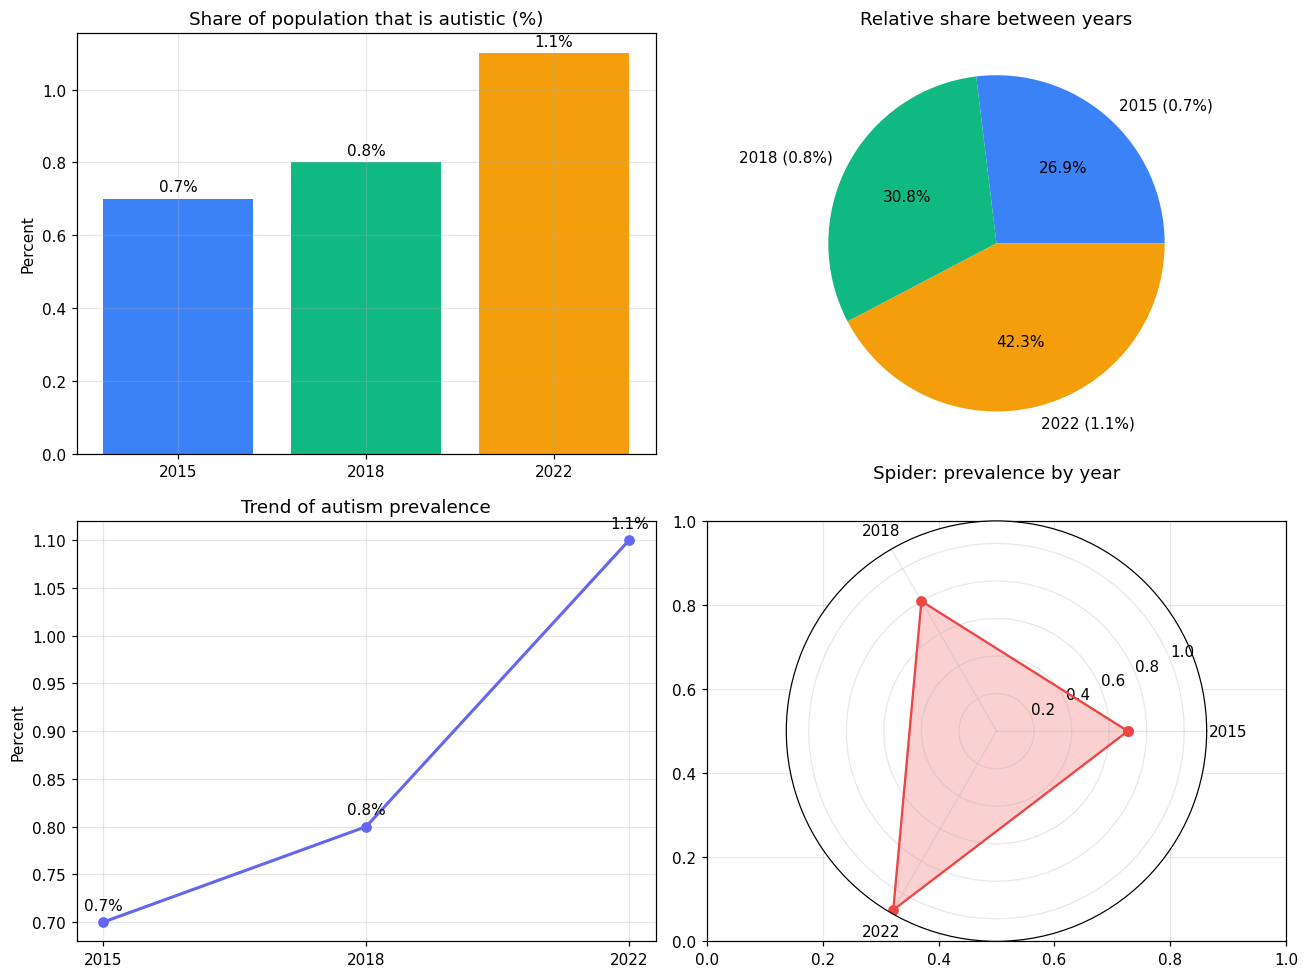

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Bar
axes[0,0].bar(YEARS, totals_pct.values, color=['#3b82f6','#10b981','#f59e0b'])
for i,v in enumerate(totals_pct.values):
    axes[0,0].text(i, v+0.02, f'{v:.1f}%', ha='center')
axes[0,0].set_title('Share of population that is autistic (%)')
axes[0,0].set_ylabel('Percent')

# Pie (relative share of total %)
axes[0,1].pie(totals_pct.values, labels=[f'{y} ({v:.1f}%)' for y,v in zip(YEARS, totals_pct.values)],
              autopct='%1.1f%%', colors=['#3b82f6','#10b981','#f59e0b'])
axes[0,1].set_title('Relative share between years')

# Line
axes[1,0].plot(YEARS, totals_pct.values, marker='o', linewidth=2, color='#6366f1')
for x,y in zip(YEARS, totals_pct.values):
    axes[1,0].annotate(f'{y:.1f}%', (x,y), textcoords='offset points', xytext=(0,8), ha='center')
axes[1,0].set_title('Trend of autism prevalence')
axes[1,0].set_ylabel('Percent')

# Spider / radar
import numpy as np
angles = np.linspace(0, 2*np.pi, len(YEARS), endpoint=False).tolist()
vals = totals_pct.values.tolist() + [totals_pct.values[0]]
angles += [angles[0]]
axes[1,1] = plt.subplot(2,2,4, projection='polar')
axes[1,1].plot(angles, vals, 'o-', color='#ef4444')
axes[1,1].fill(angles, vals, alpha=0.25, color='#ef4444')
axes[1,1].set_xticks(angles[:-1]); axes[1,1].set_xticklabels(YEARS)
axes[1,1].set_title('Spider: prevalence by year', y=1.08)

plt.tight_layout(); plt.show()

## 4. Total autistic persons — 2015 / 2018 / 2022 ('000)

In [6]:
totals_est = age_est[age_est['Age group'] == 'Total persons'].iloc[0][YEARS].astype(float)
totals_est

2015   164.00
2018   205.20
2022   290.90
Name: 10, dtype: float64

In [7]:
total_growth = growth(totals_est, '2015')
total_growth

2015 → 2018 (pp change)    41.20
2015 → 2018 (% change)     25.12
2015 → 2022 (pp change)   126.90
2015 → 2022 (% change)     77.38
dtype: float64

### Q4 charts — total autistic persons ('000)

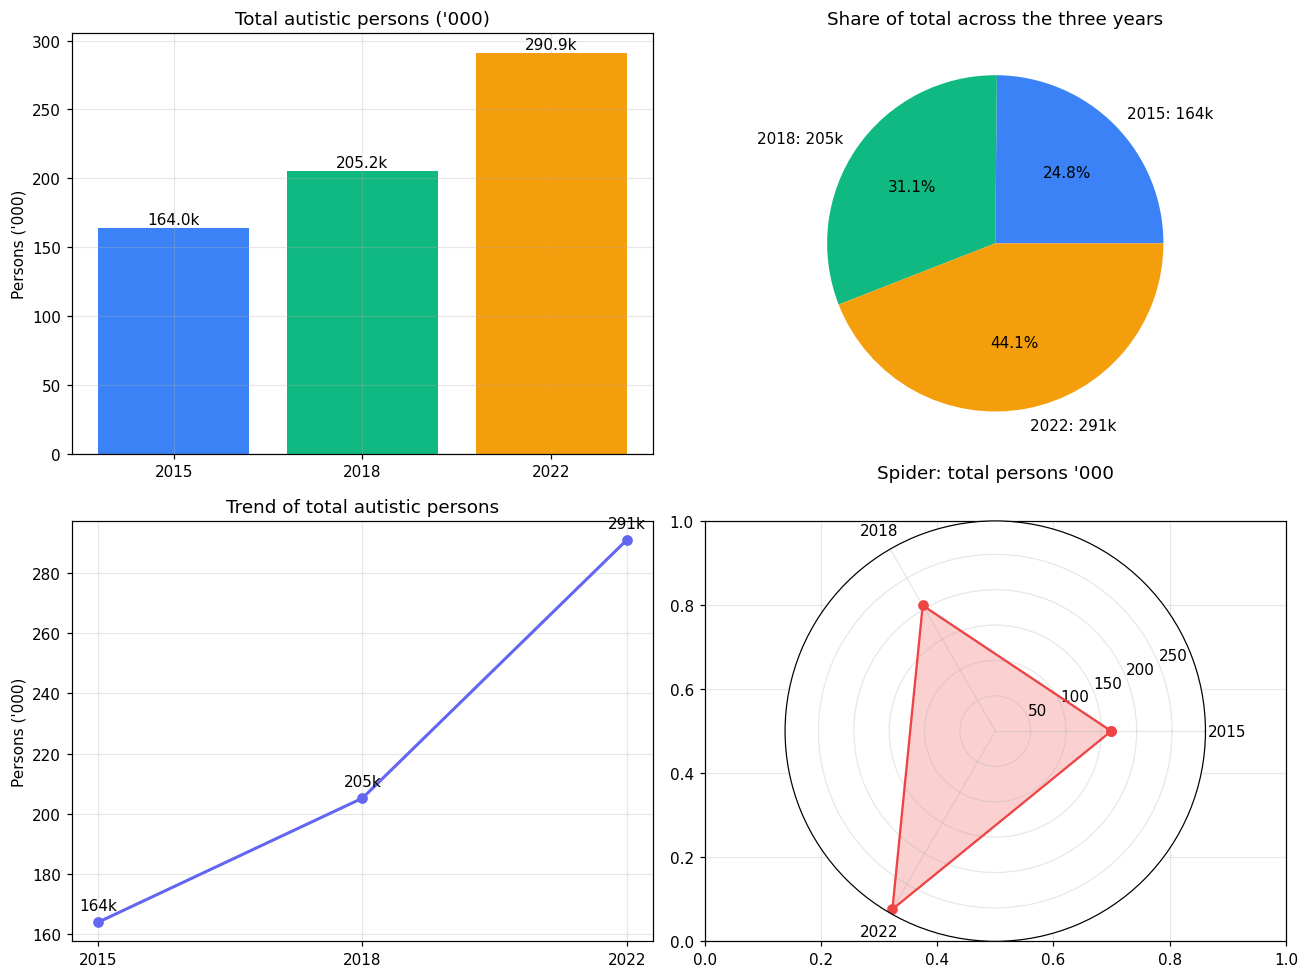

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].bar(YEARS, totals_est.values, color=['#3b82f6','#10b981','#f59e0b'])
for i,v in enumerate(totals_est.values):
    axes[0,0].text(i, v+3, f"{v:,.1f}k", ha='center')
axes[0,0].set_title("Total autistic persons ('000)")
axes[0,0].set_ylabel("Persons ('000)")

axes[0,1].pie(totals_est.values, labels=[f'{y}: {v:.0f}k' for y,v in zip(YEARS, totals_est.values)],
              autopct='%1.1f%%', colors=['#3b82f6','#10b981','#f59e0b'])
axes[0,1].set_title('Share of total across the three years')

axes[1,0].plot(YEARS, totals_est.values, marker='o', linewidth=2, color='#6366f1')
for x,y in zip(YEARS, totals_est.values):
    axes[1,0].annotate(f'{y:.0f}k', (x,y), textcoords='offset points', xytext=(0,8), ha='center')
axes[1,0].set_title('Trend of total autistic persons')
axes[1,0].set_ylabel("Persons ('000)")

angles = np.linspace(0, 2*np.pi, len(YEARS), endpoint=False).tolist()
vals = totals_est.values.tolist() + [totals_est.values[0]]
angles += [angles[0]]
axes[1,1] = plt.subplot(2,2,4, projection='polar')
axes[1,1].plot(angles, vals, 'o-', color='#ef4444')
axes[1,1].fill(angles, vals, alpha=0.25, color='#ef4444')
axes[1,1].set_xticks(angles[:-1]); axes[1,1].set_xticklabels(YEARS)
axes[1,1].set_title("Spider: total persons '000", y=1.08)

plt.tight_layout(); plt.show()

## 5. Age-wise distribution — percentage of population that is autistic

Each row is the share of that age group in the Australian population who are autistic.

In [9]:
age_groups = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40 and over']
pct_by_age = age_prop[age_prop['Age group'].isin(age_groups)].set_index('Age group')[YEARS]
pct_by_age

,2015,2018,2022
Age group,,,
0-4,0.40,0.70,0.90
5-9,2.80,3.10,3.70
10-14,2.80,3.30,4.40
15-19,1.80,2.80,3.40
20-24,1.20,1.20,2.70
25-29,0.70,0.80,0.90
30-34,0.30,0.40,0.80
35-39,0.20,0.20,0.20
40 and over,0.10,0.10,0.10


### Q5 charts — age-wise % prevalence

/sessions/eager-inspiring-turing/tmp/ipykernel_14/3844074890.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(age_groups, rotation=30)


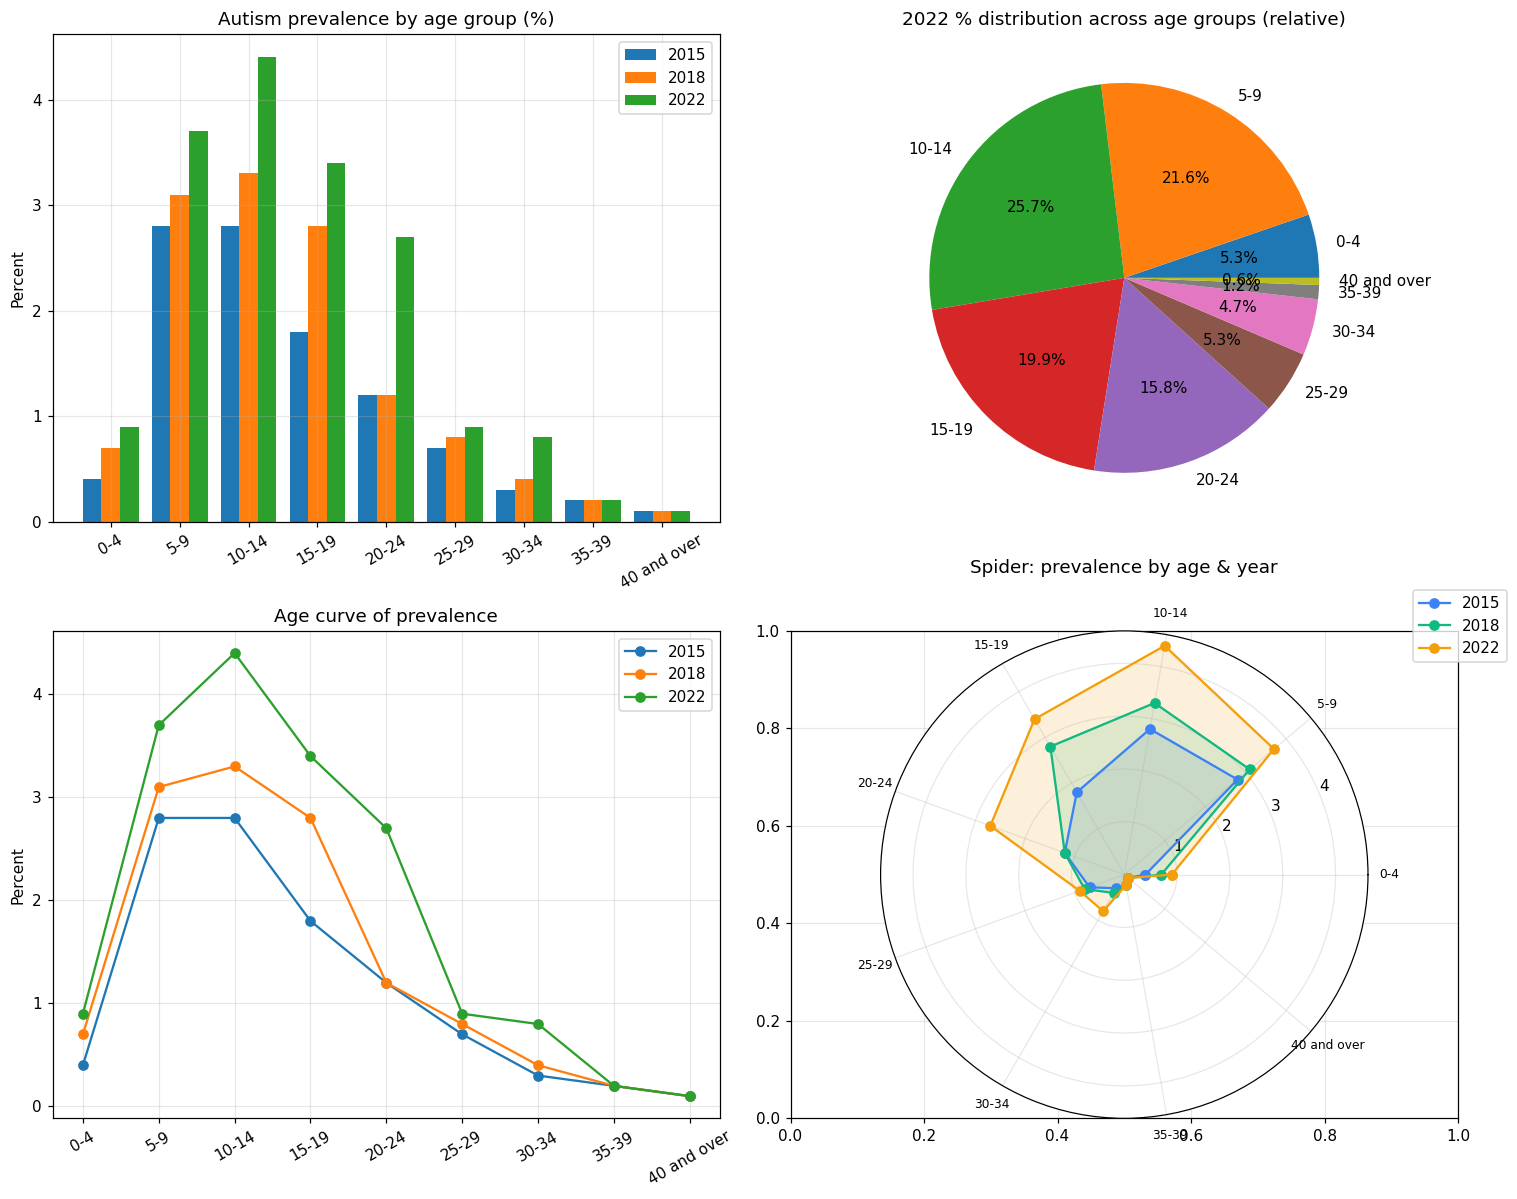

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Grouped bar
x = np.arange(len(age_groups)); w = 0.27
for i,y in enumerate(YEARS):
    axes[0,0].bar(x + (i-1)*w, pct_by_age[y].values, w, label=y)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(age_groups, rotation=30)
axes[0,0].set_title('Autism prevalence by age group (%)')
axes[0,0].set_ylabel('Percent'); axes[0,0].legend()

# Pie for 2022
axes[0,1].pie(pct_by_age['2022'].values, labels=age_groups, autopct='%1.1f%%')
axes[0,1].set_title('2022 % distribution across age groups (relative)')

# Line
for y in YEARS:
    axes[1,0].plot(age_groups, pct_by_age[y].values, marker='o', label=y)
axes[1,0].set_xticklabels(age_groups, rotation=30)
axes[1,0].set_ylabel('Percent'); axes[1,0].set_title('Age curve of prevalence')
axes[1,0].legend()

# Radar
angles = np.linspace(0, 2*np.pi, len(age_groups), endpoint=False).tolist()
axes[1,1] = plt.subplot(2,2,4, projection='polar')
for y, color in zip(YEARS, ['#3b82f6','#10b981','#f59e0b']):
    v = pct_by_age[y].values.tolist() + [pct_by_age[y].values[0]]
    a = angles + [angles[0]]
    axes[1,1].plot(a, v, 'o-', color=color, label=y)
    axes[1,1].fill(a, v, alpha=0.15, color=color)
axes[1,1].set_xticks(angles); axes[1,1].set_xticklabels(age_groups, fontsize=8)
axes[1,1].set_title('Spider: prevalence by age & year', y=1.1)
axes[1,1].legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.tight_layout(); plt.show()

## 6. Age-wise distribution — total autistic persons ('000)

In [11]:
tot_by_age = age_est[age_est['Age group'].isin(age_groups)].set_index('Age group')[YEARS]
tot_by_age

,2015,2018,2022
Age group,,,
0-4,6.20,10.80,12.80
5-9,41.90,49.00,59.00
10-14,39.40,50.30,72.00
15-19,26.40,40.20,51.40
20-24,20.00,19.80,42.50
25-29,11.90,15.60,15.60
30-34,5.10,7.10,14.40
35-39,2.50,3.50,3.50
40 and over,6.90,8.40,18.30


In [12]:
# Growth rate per age group, 2015 -> 2018 and 2015 -> 2022
growth_table = pd.DataFrame({
    '2015 → 2018 (%)': ((tot_by_age['2018']/tot_by_age['2015'])-1)*100,
    '2015 → 2022 (%)': ((tot_by_age['2022']/tot_by_age['2015'])-1)*100,
}).round(1)
growth_table

,2015 → 2018 (%),2015 → 2022 (%)
Age group,,
0-4,74.20,106.50
5-9,16.90,40.80
10-14,27.70,82.70
15-19,52.30,94.70
20-24,-1.00,112.50
25-29,31.10,31.10
30-34,39.20,182.40
35-39,40.00,40.00
40 and over,21.70,165.20


### Q6 — 2022 hierarchical treemap: *Half are still children*

| In total | Children 0 — 14 | Adults 30+ |
|---|---|---|
| **289,500 people** | **50%** (143,800) | **13%** (36,200) |

The blocks sum to 289,500 (the sum of the published age-cohort cells; the all-ages
total of 290,900 differs slightly due to ABS rounding adjustments).

### Q6 chart — 2022 hierarchical treemap (with KPI banner)

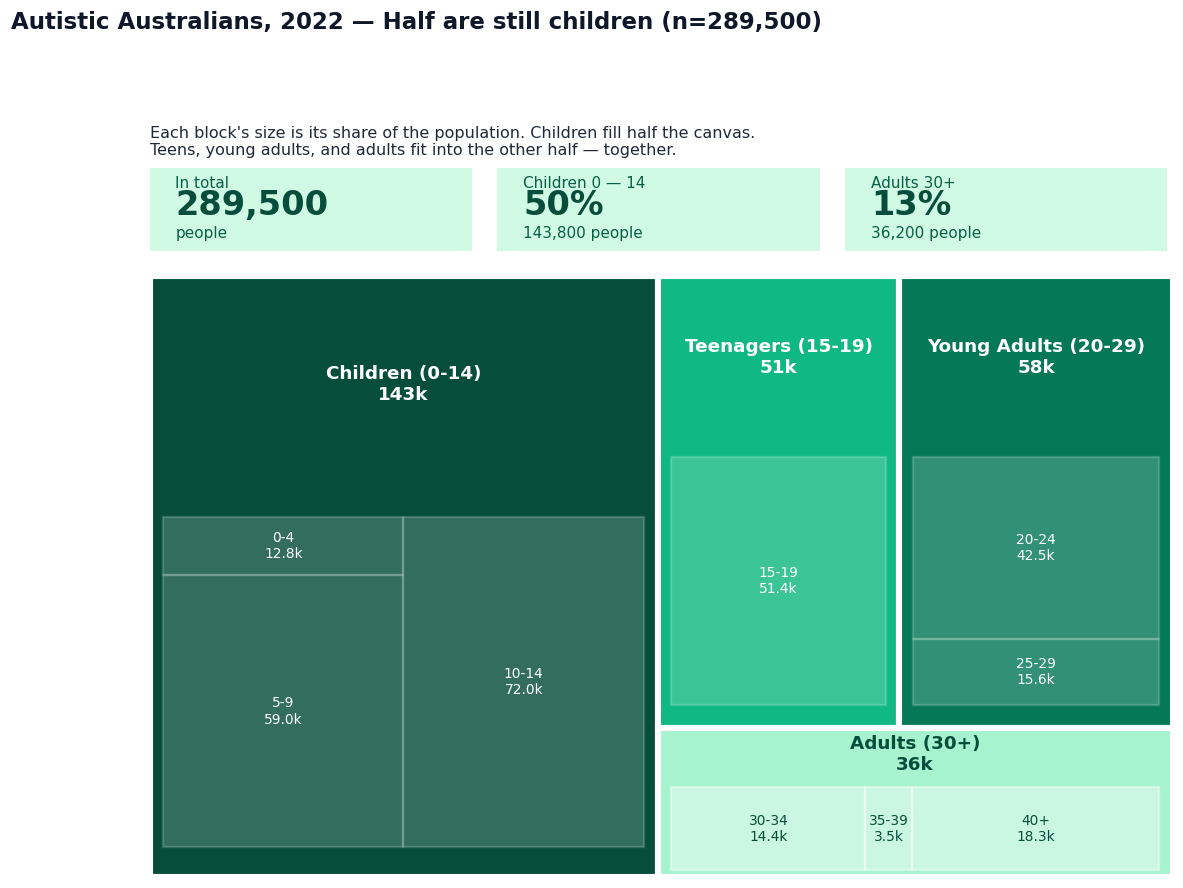

In [13]:
# 2022 treemap grouped by life-stage, using squarify, with a KPI banner above
import squarify
from matplotlib.gridspec import GridSpec

groups = {
    'Children (0-14)':     {'0-4':12.8, '5-9':59.0, '10-14':72.0},
    'Teenagers (15-19)':   {'15-19':51.4},
    'Young Adults (20-29)':{'20-24':42.5, '25-29':15.6},
    'Adults (30+)':        {'30-34':14.4, '35-39':3.5, '40+':18.3},
}
group_colors = {
    'Children (0-14)':     '#064e3b',
    'Teenagers (15-19)':   '#10b981',
    'Young Adults (20-29)':'#047857',
    'Adults (30+)':        '#a7f3d0',
}

fig = plt.figure(figsize=(12, 9))
fig.patch.set_facecolor('white')
gs = GridSpec(2, 1, height_ratios=[1, 4.2], hspace=0.05)

# ---- KPI banner ----
ax_kpi = fig.add_subplot(gs[0])
ax_kpi.set_xlim(0, 10); ax_kpi.set_ylim(0, 4); ax_kpi.axis('off')
ax_kpi.text(0, 3.7, 'Each block\'s size is its share of the population. Children fill half the canvas.\n'
                    'Teens, young adults, and adults fit into the other half — together.',
            fontsize=10.5, color='#1f2937', va='top')

cards = [
    ('In total',         '289,500', 'people'),
    ('Children 0 — 14',  '50%',     '143,800 people'),
    ('Adults 30+',       '13%',     '36,200 people'),
]
card_w, card_gap = 3.15, 0.25
x = 0
for label, value, sub in cards:
    ax_kpi.add_patch(plt.Rectangle((x, 0.2), card_w, 2.3, facecolor='#d1fae5',
                                    edgecolor='none', zorder=1))
    ax_kpi.text(x+0.25, 1.95, label, fontsize=10, color='#065f46')
    ax_kpi.text(x+0.25, 1.20, value, fontsize=22, color='#064e3b', fontweight='bold')
    ax_kpi.text(x+0.25, 0.55, sub,   fontsize=10, color='#065f46')
    x += card_w + card_gap

# ---- Treemap ----
ax = fig.add_subplot(gs[1])
outer_sizes  = [sum(v.values()) for v in groups.values()]
outer_labels = [f"{k}\n{int(sum(v.values()))}k" for k,v in groups.items()]
outer_colors = [group_colors[k] for k in groups]

outer_norm  = squarify.normalize_sizes(outer_sizes, 600, 400)
outer_rects = squarify.squarify(outer_norm, 0, 0, 600, 400)
for rect, color, label in zip(outer_rects, outer_colors, outer_labels):
    ax.add_patch(plt.Rectangle((rect['x'], rect['y']), rect['dx'], rect['dy'],
                               facecolor=color, edgecolor='white', linewidth=4))
    text_color = '#064e3b' if color == '#a7f3d0' else '#ffffff'
    ax.text(rect['x']+rect['dx']/2, rect['y']+rect['dy']*0.18, label,
            ha='center', va='center', color=text_color, fontsize=12, fontweight='bold')

for outer_rect, group_name in zip(outer_rects, groups):
    subs = groups[group_name]
    sub_sizes  = list(subs.values())
    sub_labels = [f"{k}\n{v}k" for k,v in subs.items()]
    pad = 8
    inner_norm  = squarify.normalize_sizes(sub_sizes,
                                           max(outer_rect['dx']-2*pad, 1),
                                           max(outer_rect['dy']*0.55, 1))
    inner_rects = squarify.squarify(inner_norm,
                                    outer_rect['x']+pad,
                                    outer_rect['y']+outer_rect['dy']*0.40,
                                    max(outer_rect['dx']-2*pad,1),
                                    max(outer_rect['dy']*0.55,1))
    base       = group_colors[group_name]
    text_color = '#064e3b' if base == '#a7f3d0' else '#ffffff'
    for r, lbl in zip(inner_rects, sub_labels):
        ax.add_patch(plt.Rectangle((r['x'], r['y']), r['dx'], r['dy'],
                                   facecolor='white',
                                   alpha=0.18 if base != '#a7f3d0' else 0.4,
                                   edgecolor='white', linewidth=1.5))
        ax.text(r['x']+r['dx']/2, r['y']+r['dy']/2, lbl,
                ha='center', va='center', color=text_color, fontsize=9)

ax.set_xlim(0, 600); ax.set_ylim(0, 400); ax.invert_yaxis()
ax.set_aspect('auto'); ax.axis('off')

fig.suptitle('Autistic Australians, 2022 — Half are still children (n=289,500)',
             x=0.02, y=0.985, ha='left', fontsize=15, color='#0f172a', fontweight='bold')
plt.show()

## 7. Autistic persons by activity needing assistance — totals

> **Limitation.** ABS only publishes Table 8 (activities of assistance) for **2022**.
> 2015 and 2018 are *estimated* by holding the 2022 activity-mix constant and scaling by
> the total autistic population for that year. These estimates are illustrative and clearly
> labelled below.

In [14]:
activity_items = ['Self-care','Mobility','Communication','Cognitive or emotional tasks',
                  'Health care','Reading or writing tasks','Transport(a)','Household chores',
                  'Property maintenance','Meal preparation']
act = act_est[act_est['Activity'].isin(activity_items)].set_index('Activity')

# 2022 actual
act_2022 = act['Total'].rename('2022')

# Scale to 2015 / 2018 using ratio of total autistic populations
scale_15 = totals_est['2015'] / totals_est['2022']
scale_18 = totals_est['2018'] / totals_est['2022']
activities_by_year = pd.DataFrame({
    '2015 (est.)': (act_2022 * scale_15).round(1),
    '2018 (est.)': (act_2022 * scale_18).round(1),
    '2022 (ABS)':  act_2022,
})
activities_by_year

,2015 (est.),2018 (est.),2022 (ABS)
Activity,,,
Self-care,78.20,97.80,138.70
Mobility,100.00,125.10,177.30
Communication,90.50,113.30,160.60
Cognitive or emotional tasks,125.00,156.50,221.80
Health care,72.20,90.30,128.00
Reading or writing tasks,28.80,36.00,51.10
Transport(a),32.00,40.10,56.80
Household chores,27.20,34.00,48.20
Property maintenance,27.60,34.50,48.90


In [15]:
activities_growth = pd.DataFrame({
    '2015 → 2018 (% est.)': ((activities_by_year['2018 (est.)']/activities_by_year['2015 (est.)'])-1)*100,
    '2015 → 2022 (% est.)': ((activities_by_year['2022 (ABS)']/activities_by_year['2015 (est.)'])-1)*100,
}).round(1)
activities_growth

,2015 → 2018 (% est.),2015 → 2022 (% est.)
Activity,,
Self-care,25.10,77.40
Mobility,25.10,77.30
Communication,25.20,77.50
Cognitive or emotional tasks,25.20,77.40
Health care,25.10,77.30
Reading or writing tasks,25.00,77.40
Transport(a),25.30,77.50
Household chores,25.00,77.20
Property maintenance,25.00,77.20


### Q7 chart — 2022 only, lollipop

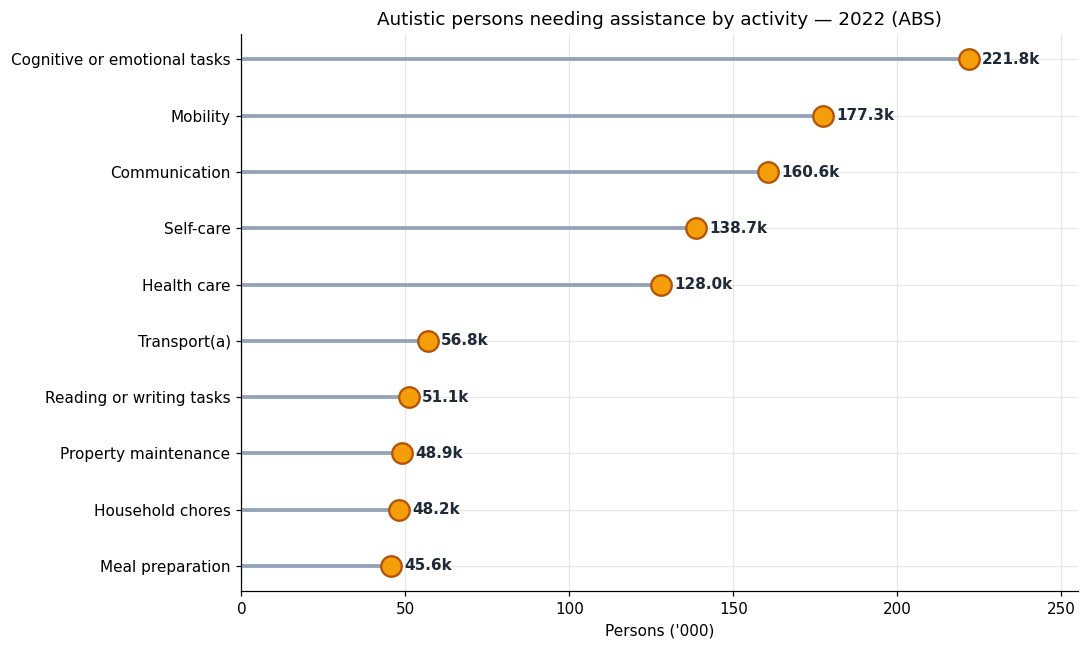

In [16]:
# 2022 lollipop: sort activities by value, draw horizontal stems + circle heads
act_2022_series = activities_by_year['2022 (ABS)'].sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(act_2022_series))
ax.hlines(y=y_pos, xmin=0, xmax=act_2022_series.values, color='#94a3b8', linewidth=2.5)
ax.scatter(act_2022_series.values, y_pos, s=180, color='#f59e0b', edgecolor='#b45309', linewidths=1.5, zorder=3)
for yi, (label, val) in enumerate(act_2022_series.items()):
    ax.text(val + 4, yi, f'{val:.1f}k', va='center', fontsize=10, color='#1f2937', fontweight='bold')
ax.set_yticks(y_pos); ax.set_yticklabels(act_2022_series.index, fontsize=10)
ax.set_xlabel("Persons ('000)")
ax.set_title('Autistic persons needing assistance by activity — 2022 (ABS)', fontsize=12)
ax.set_xlim(0, max(act_2022_series.values)*1.15)
ax.grid(axis='x', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Autistic persons by activity needing assistance — percentages

Each value is the share of the *total* autistic population in that year needing help with that activity.

In [17]:
activities_pct = pd.DataFrame({
    '2015 (est. %)': (activities_by_year['2015 (est.)']/totals_est['2015']*100).round(2),
    '2018 (est. %)': (activities_by_year['2018 (est.)']/totals_est['2018']*100).round(2),
    '2022 (ABS %)':  (activities_by_year['2022 (ABS)']/totals_est['2022']*100).round(2),
})
activities_pct

,2015 (est. %),2018 (est. %),2022 (ABS %)
Activity,,,
Self-care,47.68,47.66,47.68
Mobility,60.98,60.96,60.95
Communication,55.18,55.21,55.21
Cognitive or emotional tasks,76.22,76.27,76.25
Health care,44.02,44.01,44.00
Reading or writing tasks,17.56,17.54,17.57
Transport(a),19.51,19.54,19.53
Household chores,16.59,16.57,16.57
Property maintenance,16.83,16.81,16.81


In [18]:
# Because the activity mix is held constant, the year-over-year change in % is 0.
# We show absolute % per year alongside the implied change for completeness.
activities_pct_growth = pd.DataFrame({
    '2015 → 2018 (pp)': (activities_pct['2018 (est. %)'] - activities_pct['2015 (est. %)']).round(2),
    '2015 → 2022 (pp)': (activities_pct['2022 (ABS %)'] - activities_pct['2015 (est. %)']).round(2),
})
activities_pct_growth

,2015 → 2018 (pp),2015 → 2022 (pp)
Activity,,
Self-care,-0.02,0.00
Mobility,-0.02,-0.03
Communication,0.03,0.03
Cognitive or emotional tasks,0.05,0.03
Health care,-0.01,-0.02
Reading or writing tasks,-0.02,0.01
Transport(a),0.03,0.02
Household chores,-0.02,-0.02
Property maintenance,-0.02,-0.02


### Q8 charts — percentages by activity

/sessions/eager-inspiring-turing/tmp/ipykernel_14/3762085474.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(activity_items, rotation=35, ha='right')


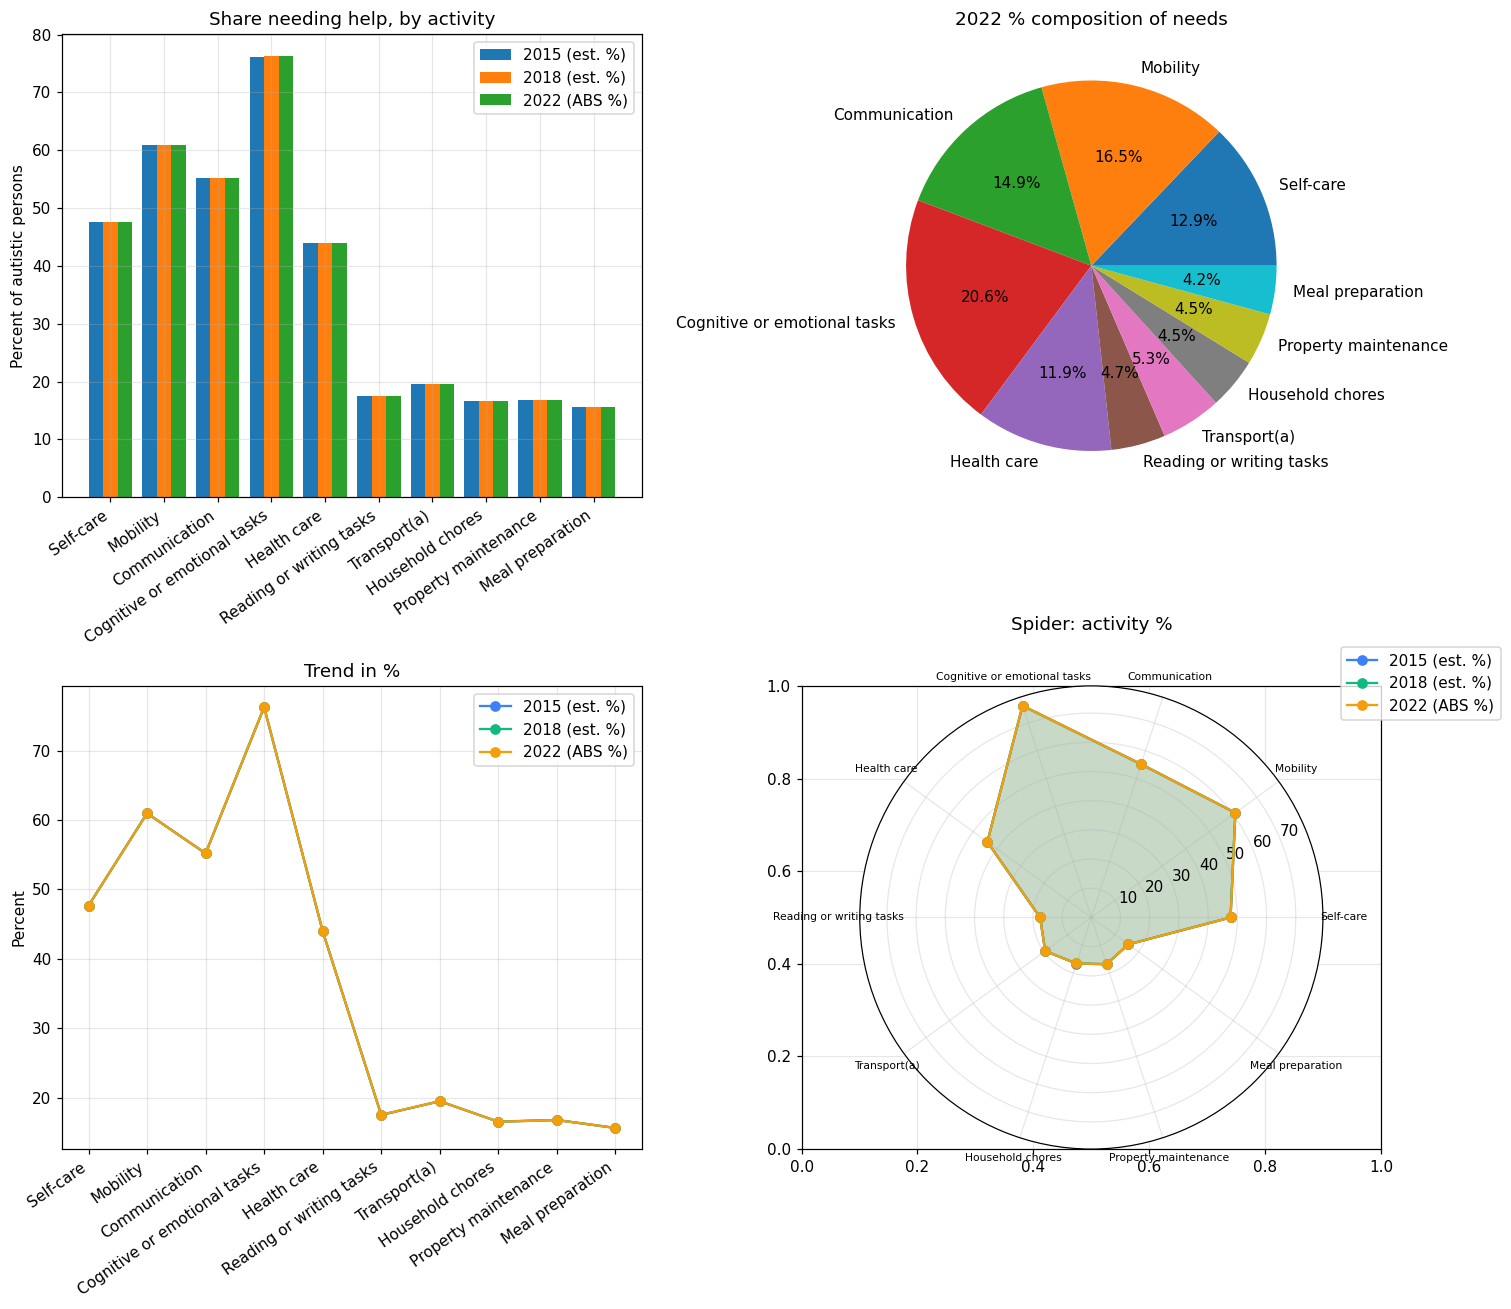

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cols = ['2015 (est. %)','2018 (est. %)','2022 (ABS %)']

x = np.arange(len(activity_items)); w = 0.27
for i,c in enumerate(cols):
    axes[0,0].bar(x + (i-1)*w, activities_pct[c].values, w, label=c)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(activity_items, rotation=35, ha='right')
axes[0,0].set_ylabel('Percent of autistic persons')
axes[0,0].set_title('Share needing help, by activity'); axes[0,0].legend()

axes[0,1].pie(activities_pct['2022 (ABS %)'].values, labels=activity_items, autopct='%1.1f%%')
axes[0,1].set_title('2022 % composition of needs')

for c, color in zip(cols, ['#3b82f6','#10b981','#f59e0b']):
    axes[1,0].plot(activity_items, activities_pct[c].values, marker='o', label=c, color=color)
axes[1,0].set_xticklabels(activity_items, rotation=35, ha='right')
axes[1,0].set_ylabel('Percent'); axes[1,0].set_title('Trend in %')
axes[1,0].legend()

angles = np.linspace(0, 2*np.pi, len(activity_items), endpoint=False).tolist()
axes[1,1] = plt.subplot(2,2,4, projection='polar')
for c, color in zip(cols, ['#3b82f6','#10b981','#f59e0b']):
    v = activities_pct[c].values.tolist() + [activities_pct[c].values[0]]
    a = angles + [angles[0]]
    axes[1,1].plot(a, v, 'o-', color=color, label=c)
    axes[1,1].fill(a, v, alpha=0.15, color=color)
axes[1,1].set_xticks(angles); axes[1,1].set_xticklabels(activity_items, fontsize=7)
axes[1,1].set_title('Spider: activity %', y=1.1)
axes[1,1].legend(loc='upper right', bbox_to_anchor=(1.4,1.1))

plt.tight_layout(); plt.show()

## 9. Activities × age group (15 to 40+) — totals

ABS does **not** publish activity-of-assistance broken down by age group. We build an
illustrative cross-tab by:
1. Taking the **age mix** of autistic persons 15+ from Table 1 (per year).
2. Multiplying that share by the **activity totals** from §7 to get an age × activity estimate.

Numbers are estimates, not ABS-published values.

In [20]:
adult_groups = ['15-19','20-24','25-29','30-34','35-39','40 and over']

# Adult share within autistic adult population (15+) per year
adult_totals = tot_by_age.loc[adult_groups]
adult_share = adult_totals.div(adult_totals.sum(axis=0), axis=1)
adult_share

,2015,2018,2022
Age group,,,
15-19,0.36,0.42,0.35
20-24,0.27,0.21,0.29
25-29,0.16,0.16,0.11
30-34,0.07,0.08,0.10
35-39,0.03,0.04,0.02
40 and over,0.09,0.09,0.13


In [21]:
# Activity totals applied to the autistic adult share (15+ subset only)
# Use the proportion of 15+ autistic persons within the all-ages total to scale activity totals
adult_pop = adult_totals.sum(axis=0)               # 15+ total per year ('000)
all_pop  = totals_est.astype(float)                 # all ages total per year ('000)
adult_fraction = adult_pop / all_pop                # fraction of autistic persons aged 15+

activity_adult = activities_by_year.rename(columns={
    '2015 (est.)':'2015', '2018 (est.)':'2018', '2022 (ABS)':'2022'}).copy()
for y in YEARS:
    activity_adult[y] = activity_adult[y] * adult_fraction[y]
activity_adult.round(1)

,2015,2018,2022
Activity,,,
Self-care,34.70,45.10,69.50
Mobility,44.40,57.70,88.80
Communication,40.20,52.20,80.40
Cognitive or emotional tasks,55.50,72.10,111.10
Health care,32.00,41.60,64.10
Reading or writing tasks,12.80,16.60,25.60
Transport(a),14.20,18.50,28.40
Household chores,12.10,15.70,24.10
Property maintenance,12.30,15.90,24.50


In [22]:
# Build the age x activity panel per year (totals)
panels_total = {}
for y in YEARS:
    panel = pd.DataFrame(
        np.outer(activity_adult[y].values, adult_share[y].values),
        index=activity_items, columns=adult_groups,
    ).round(2)
    panels_total[y] = panel
panels_total['2022']

,15-19,20-24,25-29,30-34,35-39,40 and over
Self-care,24.51,20.26,7.44,6.87,1.67,8.73
Mobility,31.33,25.90,9.51,8.78,2.13,11.15
Communication,28.38,23.46,8.61,7.95,1.93,10.10
Cognitive or emotional tasks,39.19,32.40,11.89,10.98,2.67,13.95
Health care,22.62,18.70,6.86,6.34,1.54,8.05
Reading or writing tasks,9.03,7.47,2.74,2.53,0.61,3.21
Transport(a),10.04,8.30,3.05,2.81,0.68,3.57
Household chores,8.52,7.04,2.58,2.39,0.58,3.03
Property maintenance,8.64,7.14,2.62,2.42,0.59,3.08
Meal preparation,8.06,6.66,2.45,2.26,0.55,2.87


In [23]:
# Growth across years per cell (age x activity)
growth_15_22 = (panels_total['2022'] / panels_total['2015'] - 1) * 100
growth_15_18 = (panels_total['2018'] / panels_total['2015'] - 1) * 100
print('2015 -> 2018 (%)'); display(growth_15_18.round(1))
print('2015 -> 2022 (%)'); display(growth_15_22.round(1))

2015 -> 2018 (%)


,15-19,20-24,25-29,30-34,35-39,40 and over
Self-care,52.20,-1.00,31.20,39.10,40.30,21.60
Mobility,52.20,-1.10,31.00,39.20,40.10,21.60
Communication,52.40,-1.00,31.10,39.50,39.90,21.80
Cognitive or emotional tasks,52.40,-0.90,31.20,39.10,39.80,21.90
Health care,52.20,-1.00,30.90,38.70,40.00,21.70
Reading or writing tasks,51.90,-1.10,31.10,38.90,38.60,21.50
Transport(a),52.60,-0.80,31.50,39.00,38.80,21.50
Household chores,52.10,-1.20,31.00,38.80,41.50,21.90
Property maintenance,52.30,-1.20,31.00,38.40,40.50,21.60
Meal preparation,52.40,-0.60,31.70,38.70,41.00,22.20


2015 -> 2022 (%)


,15-19,20-24,25-29,30-34,35-39,40 and over
Self-care,94.70,112.40,31.20,182.70,40.30,165.30
Mobility,94.60,112.30,31.00,182.30,40.10,164.80
Communication,94.80,112.50,31.10,182.90,39.90,165.10
Cognitive or emotional tasks,94.80,112.60,31.10,182.30,39.80,165.20
Health care,94.70,112.50,30.90,181.80,40.00,164.80
Reading or writing tasks,94.60,112.80,31.10,181.10,38.60,165.30
Transport(a),95.00,112.80,31.50,181.00,38.80,164.40
Household chores,94.50,112.00,31.00,181.20,41.50,165.80
Property maintenance,94.60,111.90,31.00,181.40,40.50,165.50
Meal preparation,94.70,112.80,31.70,182.50,41.00,165.70


### Q9 charts — age × activity totals

/sessions/eager-inspiring-turing/tmp/ipykernel_14/791700781.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(activity_items, rotation=35, ha='right')


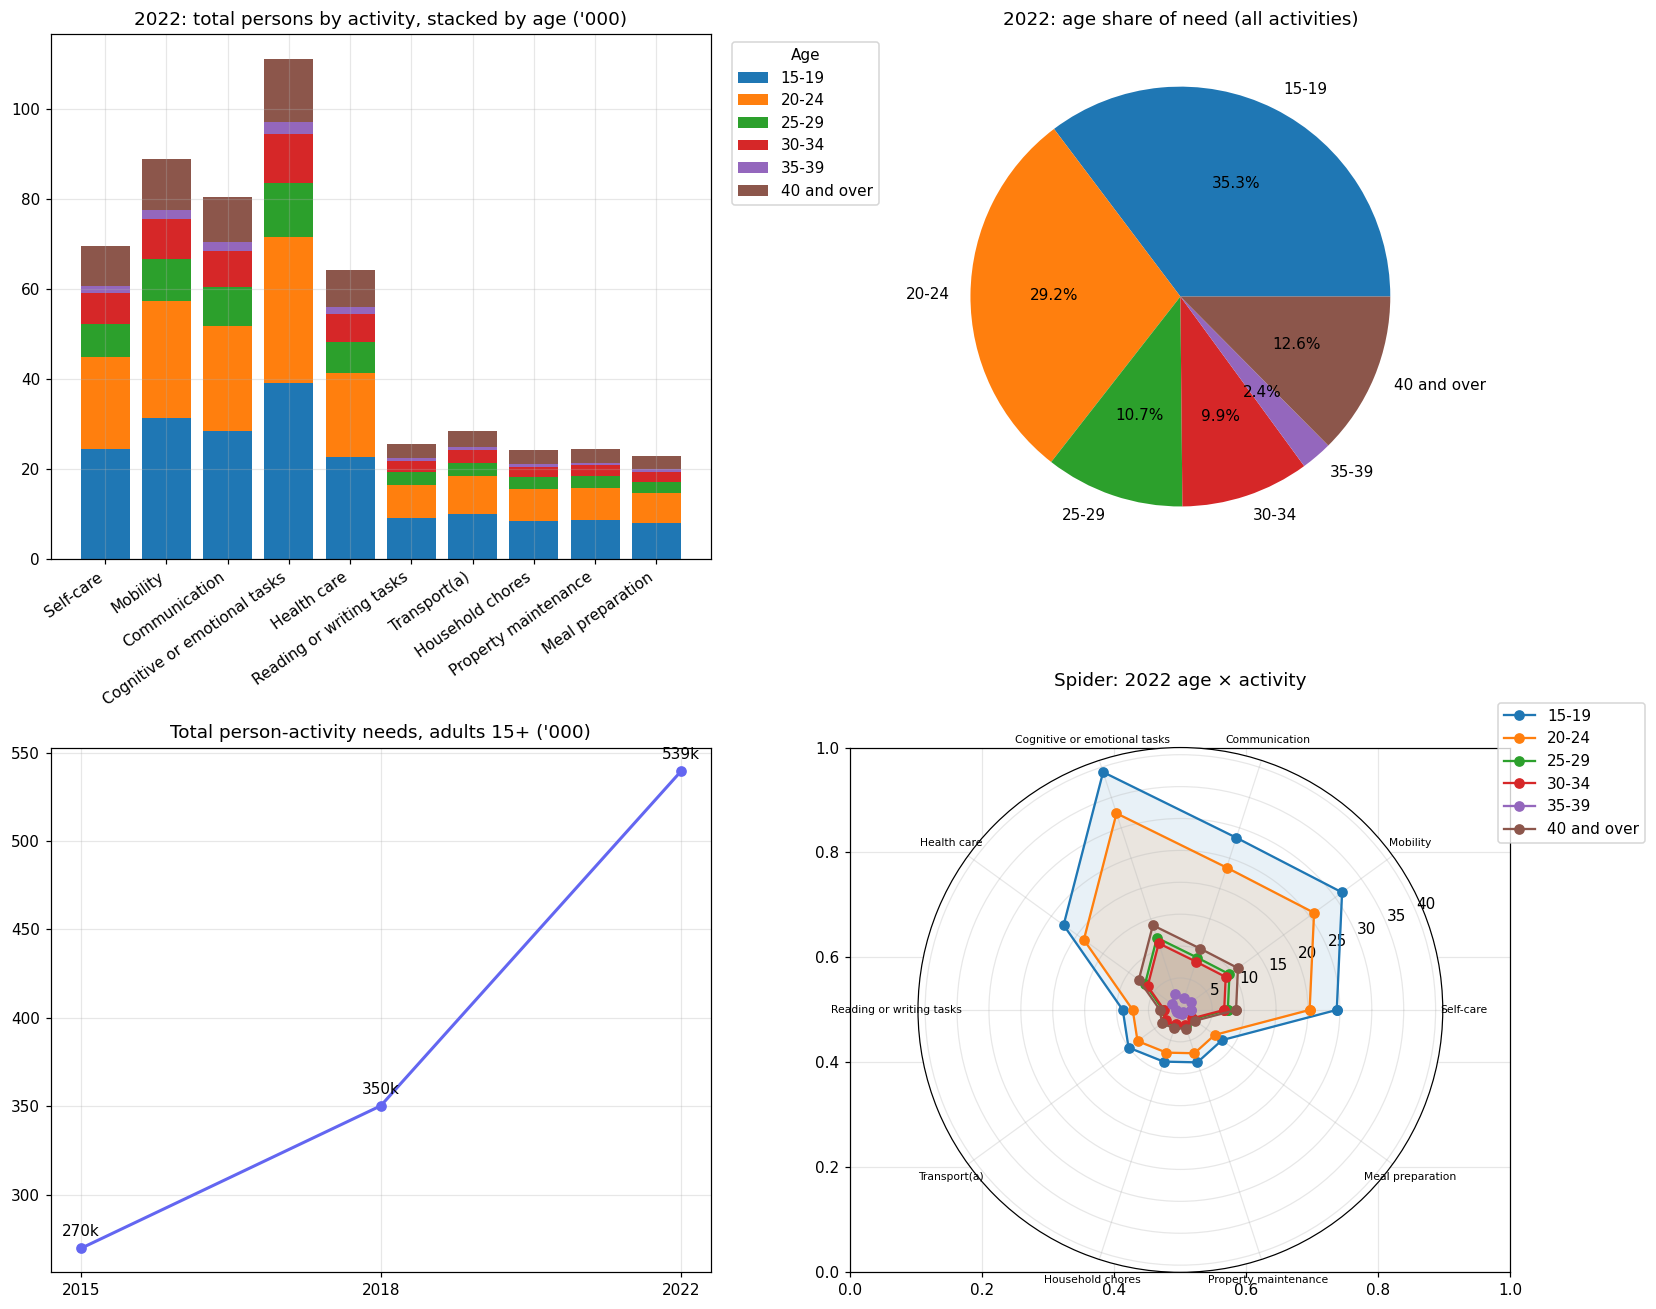

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bar: per activity, stacked by age for 2022
p2022 = panels_total['2022']
bottom = np.zeros(len(activity_items))
colors = plt.cm.tab10.colors
for i, ag in enumerate(adult_groups):
    axes[0,0].bar(activity_items, p2022[ag].values, bottom=bottom, label=ag, color=colors[i])
    bottom += p2022[ag].values
axes[0,0].set_xticklabels(activity_items, rotation=35, ha='right')
axes[0,0].set_title("2022: total persons by activity, stacked by age ('000)")
axes[0,0].legend(title='Age', bbox_to_anchor=(1.02,1), loc='upper left')

# Pie: age share of 2022 total need (across all activities)
total_by_age_2022 = p2022.sum(axis=0)
axes[0,1].pie(total_by_age_2022.values, labels=adult_groups, autopct='%1.1f%%')
axes[0,1].set_title('2022: age share of need (all activities)')

# Line: total persons (15+) needing any activity, by year
adult_totals_by_year = pd.Series({y: panels_total[y].values.sum() for y in YEARS})
axes[1,0].plot(YEARS, adult_totals_by_year.values, marker='o', linewidth=2, color='#6366f1')
for x,v in zip(YEARS, adult_totals_by_year.values):
    axes[1,0].annotate(f'{v:.0f}k', (x,v), textcoords='offset points', xytext=(0,8), ha='center')
axes[1,0].set_title("Total person-activity needs, adults 15+ ('000)")

# Radar per age group, across activities, 2022
angles = np.linspace(0, 2*np.pi, len(activity_items), endpoint=False).tolist()
axes[1,1] = plt.subplot(2,2,4, projection='polar')
for ag, color in zip(adult_groups, plt.cm.tab10.colors):
    v = p2022[ag].values.tolist() + [p2022[ag].values[0]]
    a = angles + [angles[0]]
    axes[1,1].plot(a, v, 'o-', color=color, label=ag)
    axes[1,1].fill(a, v, alpha=0.1, color=color)
axes[1,1].set_xticks(angles); axes[1,1].set_xticklabels(activity_items, fontsize=7)
axes[1,1].set_title('Spider: 2022 age × activity', y=1.1)
axes[1,1].legend(loc='upper right', bbox_to_anchor=(1.4,1.1))

plt.tight_layout(); plt.show()

## 10. Meal preparation only — across age groups 15-40+

Same prorating method as §9, isolating *Meal preparation*.

In [25]:
meal = pd.DataFrame({y: panels_total[y].loc['Meal preparation'] for y in YEARS})
meal.index.name = 'Age group'
meal.round(2)

,2015,2018,2022
Age group,,,
15-19,4.14,6.31,8.06
20-24,3.13,3.11,6.66
25-29,1.86,2.45,2.45
30-34,0.80,1.11,2.26
35-39,0.39,0.55,0.55
40 and over,1.08,1.32,2.87


In [26]:
meal_growth = pd.DataFrame({
    '2015 → 2018 (%)': ((meal['2018']/meal['2015'])-1)*100,
    '2015 → 2022 (%)': ((meal['2022']/meal['2015'])-1)*100,
}).round(1)
meal_growth

,2015 → 2018 (%),2015 → 2022 (%)
Age group,,
15-19,52.40,94.70
20-24,-0.60,112.80
25-29,31.70,31.70
30-34,38.70,182.50
35-39,41.00,41.00
40 and over,22.20,165.70


### Q10 charts — meal preparation across ages and years

/sessions/eager-inspiring-turing/tmp/ipykernel_14/2237393612.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(adult_groups, rotation=20)


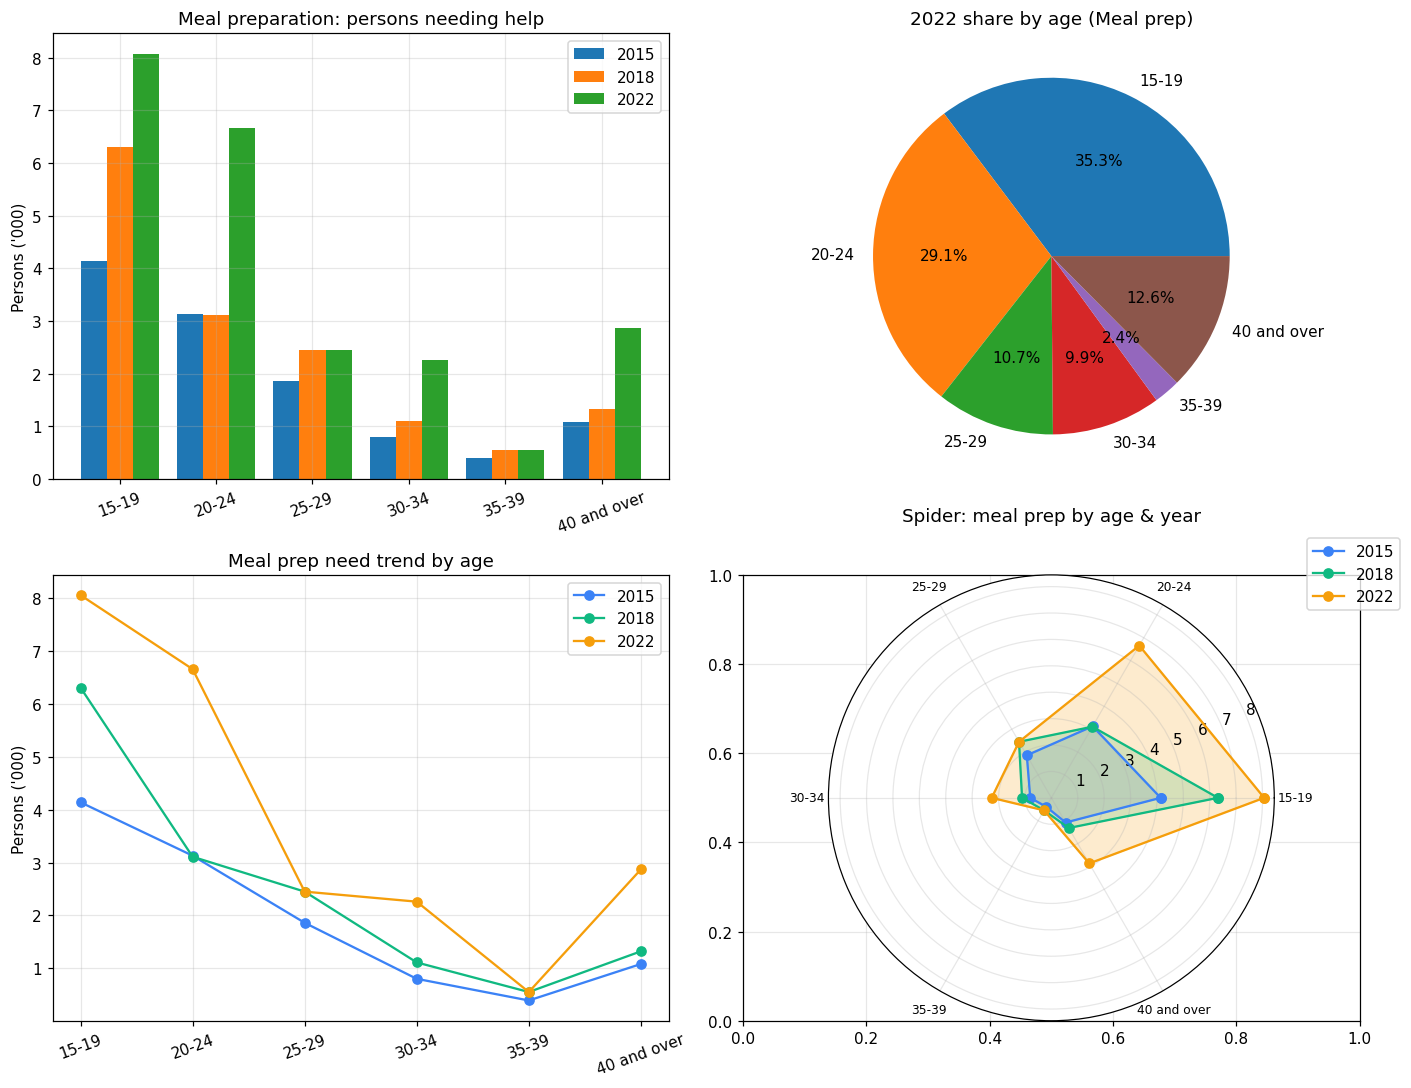

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

x = np.arange(len(adult_groups)); w = 0.27
for i,y in enumerate(YEARS):
    axes[0,0].bar(x + (i-1)*w, meal[y].values, w, label=y)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(adult_groups, rotation=20)
axes[0,0].set_ylabel("Persons ('000)")
axes[0,0].set_title('Meal preparation: persons needing help')
axes[0,0].legend()

axes[0,1].pie(meal['2022'].values, labels=adult_groups, autopct='%1.1f%%')
axes[0,1].set_title('2022 share by age (Meal prep)')

for y, color in zip(YEARS, ['#3b82f6','#10b981','#f59e0b']):
    axes[1,0].plot(adult_groups, meal[y].values, marker='o', label=y, color=color)
axes[1,0].set_xticklabels(adult_groups, rotation=20)
axes[1,0].set_ylabel("Persons ('000)")
axes[1,0].set_title('Meal prep need trend by age')
axes[1,0].legend()

angles = np.linspace(0, 2*np.pi, len(adult_groups), endpoint=False).tolist()
axes[1,1] = plt.subplot(2,2,4, projection='polar')
for y, color in zip(YEARS, ['#3b82f6','#10b981','#f59e0b']):
    v = meal[y].values.tolist() + [meal[y].values[0]]
    a = angles + [angles[0]]
    axes[1,1].plot(a, v, 'o-', color=color, label=y)
    axes[1,1].fill(a, v, alpha=0.2, color=color)
axes[1,1].set_xticks(angles); axes[1,1].set_xticklabels(adult_groups, fontsize=8)
axes[1,1].set_title('Spider: meal prep by age & year', y=1.1)
axes[1,1].legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.tight_layout(); plt.show()

## 11. Summary of key numbers

In [28]:
summary = pd.DataFrame({
    'Total autistic persons (’000)': totals_est.values,
    'Share of population (%)':         totals_pct.values,
}, index=YEARS)
summary['Persons growth vs 2015 (%)']    = ((summary['Total autistic persons (’000)']/summary['Total autistic persons (’000)'].iloc[0])-1)*100
summary['Prevalence growth vs 2015 (pp)'] = summary['Share of population (%)'] - summary['Share of population (%)'].iloc[0]
summary.round(2)

,Total autistic persons (’000),Share of population (%),Persons growth vs 2015 (%),Prevalence growth vs 2015 (pp)
2015,164.00,0.70,0.00,0.00
2018,205.20,0.80,25.12,0.10
2022,290.90,1.10,77.38,0.40


---
*Charts use Matplotlib. Activity-of-assistance values for 2015/2018 are illustrative estimates built
by scaling the 2022 activity mix to the year's total autistic population; the 2022 figures are
ABS-published.*